<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cgpa          100 non-null    float64
 1   resume_score  100 non-null    float64
 2   placed        100 non-null    int64  
 3   gender        100 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ KB


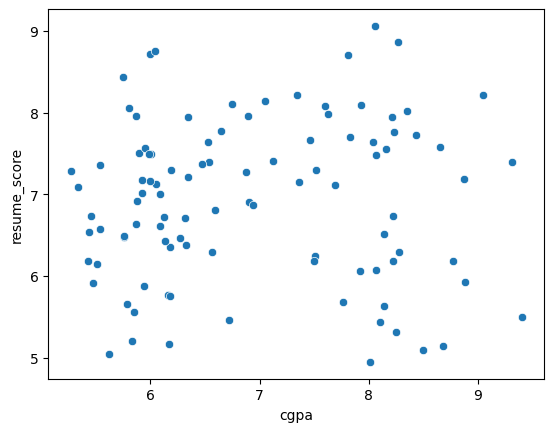

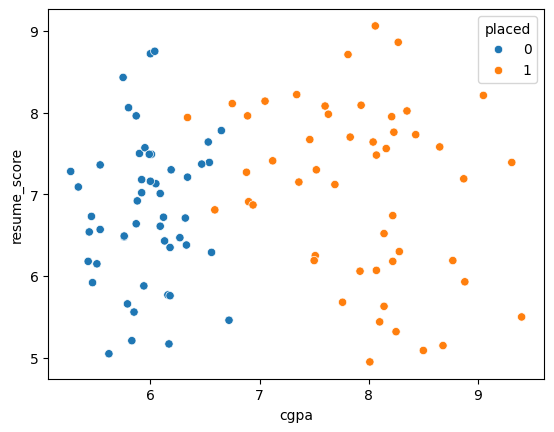

Training Accuracy: 0.975
Polynomial Perceptron Matrix
[[11  0]
 [ 1  8]]
Polynomial Perceptron Report
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.89      0.94         9

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


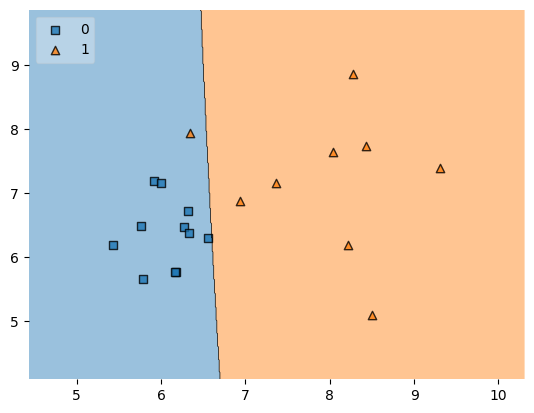

In [1]:
# Libraries loading
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report, confusion_matrix
from mlxtend.plotting import plot_decision_regions

# Data read
df = pd.read_csv("placement_gender.csv")
df.columns = df.columns.str.strip()

df.head()
df.info()
df.describe()
df.describe(include="object")

# Scatter plot without highlighting placement
sns.scatterplot(x=df.cgpa, y=df.resume_score)
plt.show()

# Scatter plot highlighting placement
sns.scatterplot(x=df.cgpa, y=df.resume_score, hue=df.placed)
plt.show()

# Split data
X = df.drop(columns=["placed", "gender"])
Y = df["placed"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

# Pipeline and model fitting
poly_perceptron_model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    Perceptron(penalty='elasticnet', alpha=0.0001, random_state=42)
)

poly_perceptron_model.fit(X_train, Y_train)
y_pred_poly = poly_perceptron_model.predict(X_test)

# Scores and metrics
train_score = poly_perceptron_model.score(X_train, Y_train)
print("Training Accuracy:", train_score)

print("Polynomial Perceptron Matrix")
print(confusion_matrix(Y_test, y_pred_poly))

print("Polynomial Perceptron Report")
print(classification_report(Y_test, y_pred_poly))

# Side-by-side comparison
comparison_df = pd.DataFrame({
    "Actual": Y_test,
    "predicted": y_pred_poly
})
comparison_df.head(10)

# Final plot
plot_decision_regions(X=X_test.values, y=Y_test.values, clf=poly_perceptron_model, legend=2)
plt.show()
